TensorFlow and Tensor Fundamentals

This section demonstrates basic tensor structures such as scalars, vectors, and matrices.
Understanding tensor shapes and data types is important because most deep learning errors come from incorrect data dimensions.

In [33]:
import tensorflow as tf
import numpy as np

print("TensorFlow version:", tf.__version__)

# Basic tensors
scalar = tf.constant(7)
vector = tf.constant([10, 20, 30])
matrix = tf.constant([[1., 2.], [3., 4.]])
tensor = tf.constant([[[1],[2]], [[3],[4]]])

print("Tensor shapes:")
print(scalar.shape, vector.shape, matrix.shape, tensor.shape)

# Data types and casting
x = tf.constant([1.7, 7.4])
y = tf.constant([7, 10])

x16 = tf.cast(x, tf.float16)
y32 = tf.cast(y, tf.float32)

# Basic operations
A = tf.constant([[10., 7.], [3., 4.]])
print("A + 10:\n", A + 10)
print("A * 2:\n", A * 2)


TensorFlow version: 2.20.0
Tensor shapes:
() (3,) (2, 2) (2, 2, 1)
A + 10:
 tf.Tensor(
[[20. 17.]
 [13. 14.]], shape=(2, 2), dtype=float32)
A * 2:
 tf.Tensor(
[[20. 14.]
 [ 6.  8.]], shape=(2, 2), dtype=float32)


Regression with Neural Networks

Regression predicts continuous numerical values.
A simple neural network is trained to learn the linear relationship y = x + 10 and generalize to unseen data.

Test MAE: 16.250732421875
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


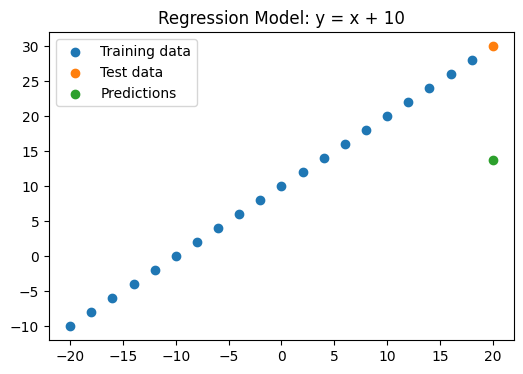

In [34]:
import matplotlib.pyplot as plt

# Dataset
X = np.arange(-20, 21, 2, dtype=np.float32)
y = X + 10

# Train/test split
X_train, y_train = X[:20], y[:20]
X_test, y_test = X[20:], y[20:]

# Model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(1)
])

model.compile(
    loss="mae",
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    metrics=["mae"]
)

model.fit(X_train, y_train, epochs=200, verbose=0)

loss, mae = model.evaluate(X_test, y_test, verbose=0)
print("Test MAE:", mae)

# Visualization
y_pred = model.predict(X_test).squeeze()

plt.figure(figsize=(6,4))
plt.scatter(X_train, y_train, label="Training data")
plt.scatter(X_test, y_test, label="Test data")
plt.scatter(X_test, y_pred, label="Predictions")
plt.legend()
plt.title("Regression Model: y = x + 10")
plt.show()


Binary Classification (Non-Linear Data)

Binary classification predicts one of two classes.
A non-linear dataset is used to show how activation functions like ReLU and sigmoid help the network learn curved decision boundaries.

In [35]:
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# Dataset
X, y = make_circles(n_samples=1000, noise=0.03, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=["accuracy"]
)

model.fit(X_train, y_train, epochs=25, verbose=0)

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print("Binary classification accuracy:", acc)


Binary classification accuracy: 1.0


Multiclass Classification – Fashion MNIST

Multiclass classification predicts one of several categories.
Images are normalized to improve training stability.
A softmax output layer produces probabilities for ten classes.

In [36]:
# Load dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.1,
    verbose=0
)

loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Multiclass classification accuracy:", acc)


4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Multiclass classification accuracy: 0.8741999864578247


Convolutional Neural Network (CNN)

CNNs are designed for image data because they preserve spatial structure.
Convolution and pooling layers extract visual features such as edges and shapes.
This model classifies two Fashion-MNIST classes: Sneaker vs Ankle Boot.

In [37]:
# Load dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Filter classes
train_mask = np.isin(y_train, [7, 9])
test_mask = np.isin(y_test, [7, 9])

x_train = x_train[train_mask][..., None] / 255.0
y_train = (y_train[train_mask] == 9).astype(np.float32)

x_test = x_test[test_mask][..., None] / 255.0
y_test = (y_test[test_mask] == 9).astype(np.float32)

# CNN Model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(16, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.fit(
    x_train, y_train,
    epochs=5,
    validation_split=0.1,
    verbose=0
)

loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("CNN accuracy:", acc)


CNN accuracy: 0.9729999899864197
